In [1]:
# Step 1: Specify the path to the "experiment_analyses" folder in your system (after cloning the repo)
# This step is because I have a separate folder in the repo that contains the Jupyter Notebooks for organization purposes
import warnings
import os
experiment_analyses_dir = r"C:\Users\graci\OneDrive\Documents\Github\driving_exp_1_analyses\experiment_analyses"  # Replace with your desired directory
os.chdir(experiment_analyses_dir)


# Step 2: Specify the location of file paths contain the main_data folder
# I will share a Dropbox folder with you that contains these folders, so you can just copy and paste your file system file path to these
# Note that the files in these folders should be treated as immutable
import preprocess

SUBJECT_PATH = "C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/main_data" # Dropbox directory path that leads to the csv files for all subejcts across both familiar and unfamiliar group

# subject_dict: all keys are of each subject's id (e.g. "wad") and all values are of the subject_object (which will contain all the data for the subject)

warnings.filterwarnings("ignore")
subject_dict = preprocess.run(SUBJECT_PATH)

In [2]:
# Useful references -------------------------
familiar_group_ids = ["baggy","bash","boned","cargo","five","grip","judge","mule","poker","polio","rerun","slate","slept","trial","yeast"] 
unfamiliar_group_ids = ["atom","blank","brim", "chef", "clerk", "debt","filth", "grid", "lens", "limb", "most","proof","slimy", "swarm","wok"]
trial_list = [0,1,2,3,4,5,6,7,8,9,10] # I use 0th based lists to index the trials 

# Pick a trial number! -----------
trial_number = 9


In [3]:
import avg_heatmap

centerline_speed_dict_list_familiar,centerline_speed_dict_list_unfamiliar = [],[]

# For every subject:
for subject_id in subject_dict:
    subject_object = subject_dict[subject_id] 
    trial_object = subject_object.trials[trial_number]

    track_centerline_x,track_centerline_y = trial_object.map.centerline_df['x'],trial_object.map.centerline_df['y']  # centerline
    speed_df = trial_object.paths["Vehicle_DrivingSim"][["velocity_magnitude","time"]] # DF for position over time
    position_df = trial_object.paths["main_camera"][["pos_x","pos_y","time"]] # DF for position over time

    # For every point along the center_line, get speed
    centerline_speed_dict = avg_heatmap.get_speeds_along_centerline(track_centerline_x, track_centerline_y, speed_df, position_df)

    if subject_object.condition == "familiar":
        centerline_speed_dict_list_familiar.append(centerline_speed_dict)
    elif subject_object.condition == "unfamiliar":
        centerline_speed_dict_list_unfamiliar.append(centerline_speed_dict)

#  Master dictionary that specifies average speed for all subjects for each point along centerline
familiar_avg_speeds_dict = avg_heatmap.average_centerline_speeds(centerline_speed_dict_list_familiar)
unfamiliar_avg_speeds_dict = avg_heatmap.average_centerline_speeds(centerline_speed_dict_list_unfamiliar)


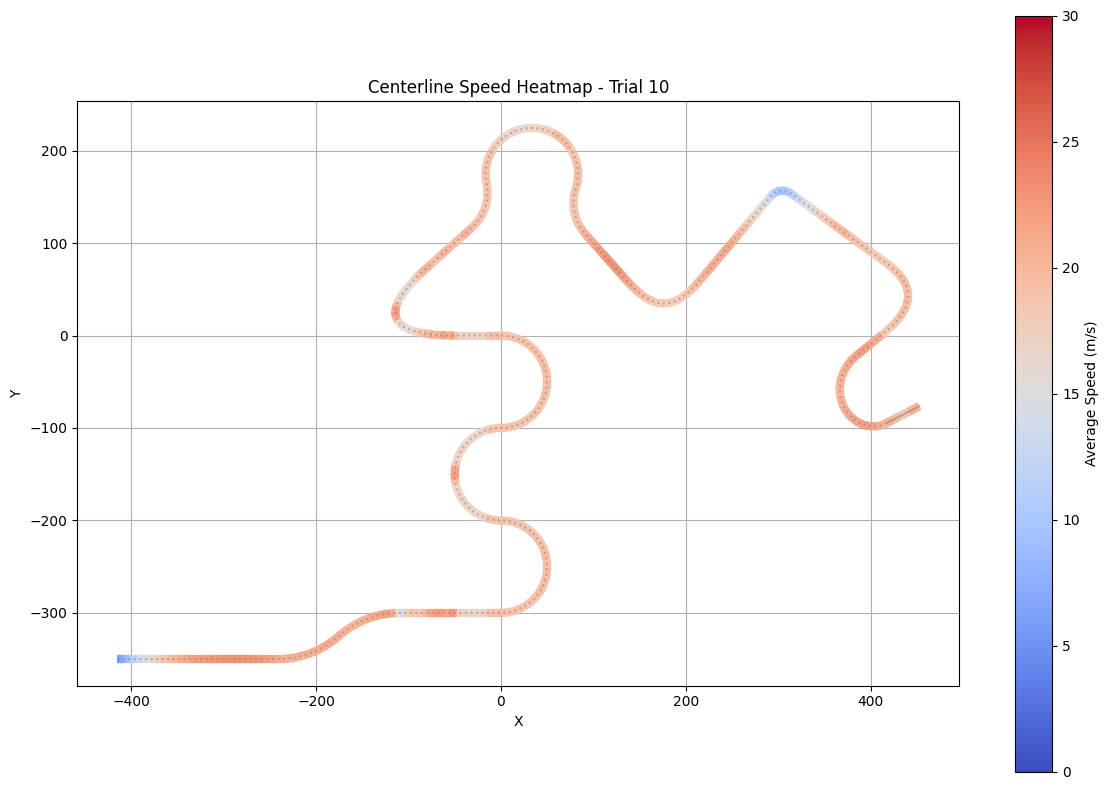

In [4]:
# Plot the heatmap! 
avg_heatmap.plot_centerline_speed_heatmap(track_centerline_x, track_centerline_y, familiar_avg_speeds_dict,trial_number)

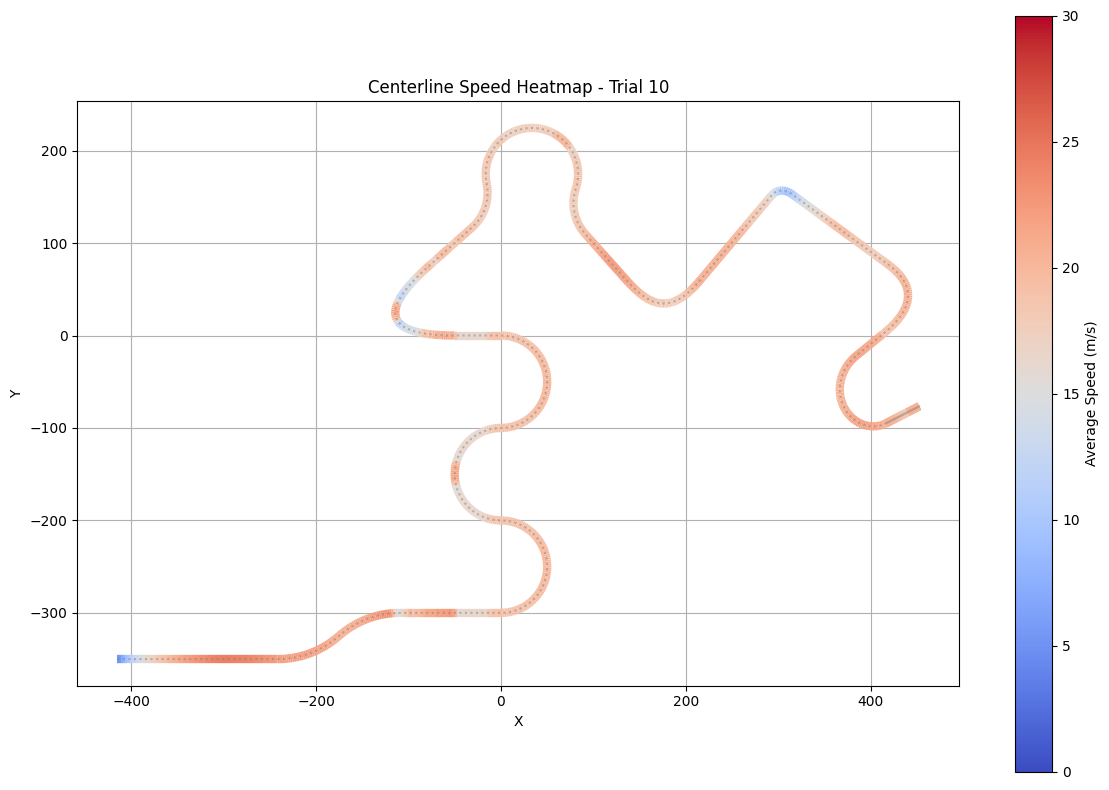

In [5]:
avg_heatmap.plot_centerline_speed_heatmap(track_centerline_x, track_centerline_y, unfamiliar_avg_speeds_dict,trial_number)